# Matrices and Matrix Operations

**Based on CS229 Linear Algebra Review - Section 2**

Matrices are fundamental to machine learning. They represent datasets, transformations, and relationships between variables. In this notebook, we'll explore matrix operations and their Python implementations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8')
np.random.seed(42)

## 1. What is a Matrix?

### Mathematical Definition
A matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ is a rectangular array of real numbers with $m$ rows and $n$ columns:

$$\mathbf{A} = \begin{bmatrix} 
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix}$$

### In Machine Learning
- **Data matrix**: Each row is a sample, each column is a feature
- **Transformation**: Linear mappings between vector spaces
- **Parameters**: Model weights and coefficients

In [2]:
# Creating matrices in NumPy

# Method 1: From a list of lists
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"Matrix A:")
print(A)
print(f"Shape: {A.shape} (2 rows, 3 columns)")
print(f"Size: {A.size} elements")

# Method 2: Using NumPy functions
B = np.zeros((3, 3))  # 3x3 matrix of zeros
C = np.ones((2, 4))   # 2x4 matrix of ones
D = np.eye(3)         # 3x3 identity matrix
E = np.random.rand(2, 3)  # 2x3 random matrix

print(f"\nZeros matrix B:")
print(B)
print(f"\nOnes matrix C:")
print(C)
print(f"\nIdentity matrix D:")
print(D)
print(f"\nRandom matrix E:")
print(E)

Matrix A:
[[1 2 3]
 [4 5 6]]
Shape: (2, 3) (2 rows, 3 columns)
Size: 6 elements

Zeros matrix B:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Ones matrix C:
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Identity matrix D:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Random matrix E:
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]]


## 2. Matrix Indexing and Slicing

### Accessing Elements
- $a_{ij}$ is the element in row $i$, column $j$ (1-indexed in math, 0-indexed in Python)
- Rows and columns can be extracted as vectors

In [3]:
# Matrix indexing and slicing
M = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9, 10, 11, 12]])

print(f"Matrix M:")
print(M)
print()

# Access single element
print(f"Element at position (0,2): {M[0, 2]}")
print(f"Element at position (2,1): {M[2, 1]}")

# Access entire rows
print(f"\nFirst row: {M[0, :]}")
print(f"Second row: {M[1, :]}")

# Access entire columns
print(f"\nFirst column: {M[:, 0]}")
print(f"Third column: {M[:, 2]}")

# Submatrices
print(f"\nTop-left 2x2 submatrix:")
print(M[0:2, 0:2])

print(f"\nLast two rows, last two columns:")
print(M[1:, 2:])

Matrix M:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Element at position (0,2): 3
Element at position (2,1): 10

First row: [1 2 3 4]
Second row: [5 6 7 8]

First column: [1 5 9]
Third column: [ 3  7 11]

Top-left 2x2 submatrix:
[[1 2]
 [5 6]]

Last two rows, last two columns:
[[ 7  8]
 [11 12]]


## 3. Matrix Addition and Scalar Multiplication

### Mathematical Definition
For matrices $\mathbf{A}, \mathbf{B} \in \mathbb{R}^{m \times n}$:

**Addition**: $(\mathbf{A} + \mathbf{B})_{ij} = a_{ij} + b_{ij}$

**Scalar multiplication**: $(\alpha \mathbf{A})_{ij} = \alpha a_{ij}$

**Note**: Matrices must have the same dimensions for addition.

Matrix A:
[[1 2]
 [3 4]]

Matrix B:
[[5 6]
 [7 8]]

A + B:
[[ 6  8]
 [10 12]]

A - B:
[[-4 -4]
 [-4 -4]]

3 * A:
[[ 3  6]
 [ 9 12]]

A * B (element-wise multiplication):
[[ 5 12]
 [21 32]]


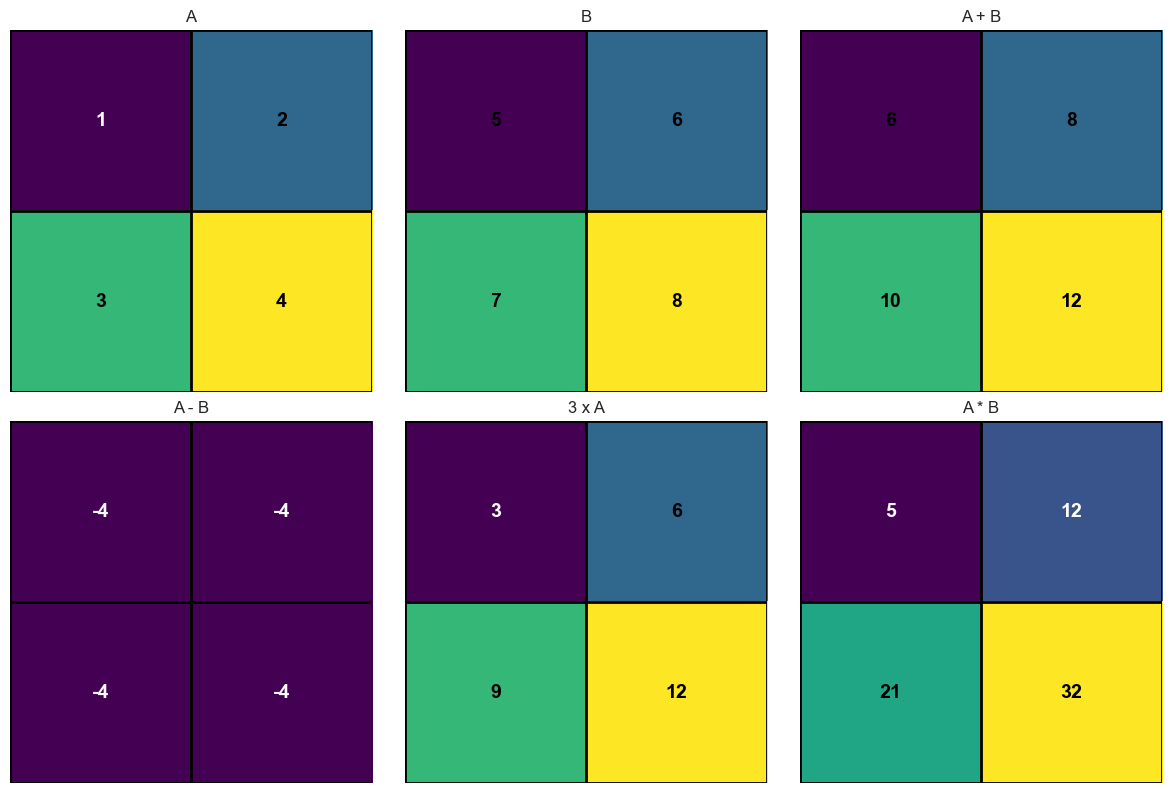

In [13]:
# Matrix addition and scalar multiplication
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print(f"Matrix A:")
print(A)
print(f"\nMatrix B:")
print(B)

# Matrix addition
C = A + B
print(f"\nA + B:")
print(C)

# Matrix subtraction
D = A - B
print(f"\nA - B:")
print(D)

# Scalar multiplication
E = 3 * A
print(f"\n3 * A:")
print(E)

# Element-wise operations
F = A * B  # Element-wise multiplication (Hadamard product)
print(f"\nA * B (element-wise multiplication):")
print(F)

# Visualize matrix operations
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
matrices = [A, B, C, D, E, F]
titles = ['A', 'B', 'A + B', 'A - B', '3 x A', 'A * B']

for i, (mat, title) in enumerate(zip(matrices, titles)):
    row, col = i // 3, i % 3
    im = axes[row, col].imshow(mat, cmap='viridis', aspect='equal')
    axes[row, col].set_title(title)
    
    # Add text annotations
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            axes[row, col].text(c, r, f'{mat[r,c]:.0f}', 
                               ha='center', va='center', 
                               color='white' if mat[r,c] < mat.max()/2 else 'black',
                               fontsize=14, fontweight='bold')
    
    # Add grid lines with black borders
    axes[row, col].set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    axes[row, col].set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    axes[row, col].grid(which='minor', color='black', linestyle='-', linewidth=2)
    axes[row, col].set_xticks([])
    axes[row, col].set_yticks([])

plt.tight_layout()
plt.show()

## 4. Matrix Multiplication

### Mathematical Definition
For $\mathbf{A} \in \mathbb{R}^{m \times n}$ and $\mathbf{B} \in \mathbb{R}^{n \times p}$:

$$(\mathbf{AB})_{ij} = \sum_{k=1}^n a_{ik} b_{kj}$$

**Key requirements**:
- Number of columns in $\mathbf{A}$ must equal number of rows in $\mathbf{B}$
- Result is $m \times p$ matrix

### Geometric Interpretation
Matrix multiplication represents composition of linear transformations.

In [14]:
# Matrix multiplication
A = np.array([[1, 2, 3],
              [4, 5, 6]])
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])

print(f"Matrix A (2x3):")
print(A)
print(f"\nMatrix B (3x2):")
print(B)

# Matrix multiplication using @
C = A @ B
print(f"\nA @ B (2x2):")
print(C)

# Alternative: using np.dot
C_alt = np.dot(A, B)
print(f"\nUsing np.dot (same result):")
print(C_alt)

# Manual calculation for verification
print(f"\nManual calculation:")
print(f"C[0,0] = A[0,:] · B[:,0] = {A[0,:]} · {B[:,0]} = {np.dot(A[0,:], B[:,0])}")
print(f"C[0,1] = A[0,:] · B[:,1] = {A[0,:]} · {B[:,1]} = {np.dot(A[0,:], B[:,1])}")
print(f"C[1,0] = A[1,:] · B[:,0] = {A[1,:]} · {B[:,0]} = {np.dot(A[1,:], B[:,0])}")
print(f"C[1,1] = A[1,:] · B[:,1] = {A[1,:]} · {B[:,1]} = {np.dot(A[1,:], B[:,1])}")

# Dimension compatibility check
print(f"\nDimension compatibility:")
print(f"A.shape = {A.shape}, B.shape = {B.shape}")
print(f"A has {A.shape[1]} columns, B has {B.shape[0]} rows")
print(f"Since {A.shape[1]} == {B.shape[0]}, multiplication is valid")
print(f"Result shape: ({A.shape[0]}, {B.shape[1]}) = {C.shape}")

Matrix A (2x3):
[[1 2 3]
 [4 5 6]]

Matrix B (3x2):
[[ 7  8]
 [ 9 10]
 [11 12]]

A @ B (2x2):
[[ 58  64]
 [139 154]]

Using np.dot (same result):
[[ 58  64]
 [139 154]]

Manual calculation:
C[0,0] = A[0,:] · B[:,0] = [1 2 3] · [ 7  9 11] = 58
C[0,1] = A[0,:] · B[:,1] = [1 2 3] · [ 8 10 12] = 64
C[1,0] = A[1,:] · B[:,0] = [4 5 6] · [ 7  9 11] = 139
C[1,1] = A[1,:] · B[:,1] = [4 5 6] · [ 8 10 12] = 154

Dimension compatibility:
A.shape = (2, 3), B.shape = (3, 2)
A has 3 columns, B has 3 rows
Since 3 == 3, multiplication is valid
Result shape: (2, 2) = (2, 2)


## 5. Matrix-Vector Multiplication

### Mathematical Definition
For $\mathbf{A} \in \mathbb{R}^{m \times n}$ and $\mathbf{x} \in \mathbb{R}^n$:

$$\mathbf{Ax} = \begin{bmatrix} 
\mathbf{a}_1^T \mathbf{x} \\
\mathbf{a}_2^T \mathbf{x} \\
\vdots \\
\mathbf{a}_m^T \mathbf{x}
\end{bmatrix}$$

where $\mathbf{a}_i^T$ is the $i$-th row of $\mathbf{A}$.

### In Machine Learning
This is fundamental for:
- Linear regression: $\hat{y} = \mathbf{Ax}$
- Neural networks: forward propagation
- Feature transformations

Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Vector x: [1 2 1]

A @ x = [ 8 20 32]

Row-wise computation:
Row 0: [1 2 3] · [1 2 1] = 8
Row 1: [4 5 6] · [1 2 1] = 20
Row 2: [7 8 9] · [1 2 1] = 32


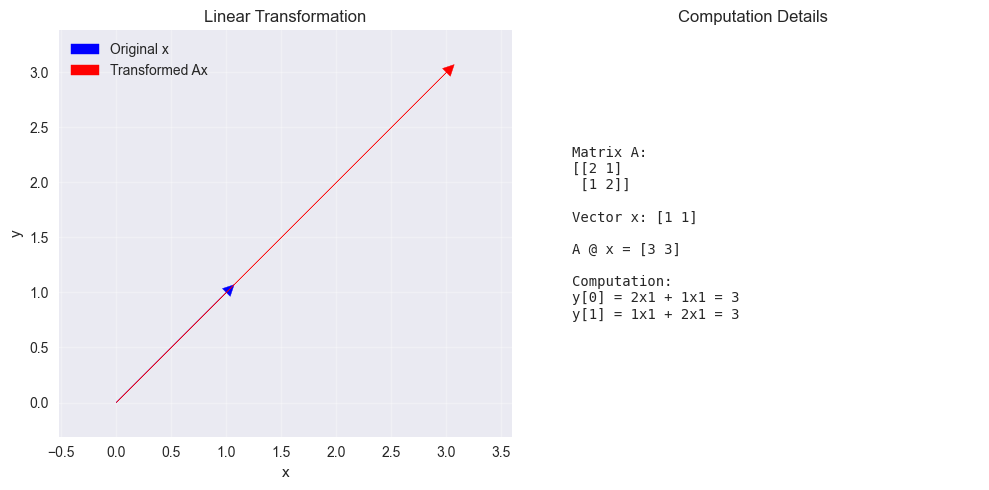

In [15]:
# Matrix-vector multiplication
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
x = np.array([1, 2, 1])

print(f"Matrix A:")
print(A)
print(f"\nVector x: {x}")

# Matrix-vector multiplication
y = A @ x
print(f"\nA @ x = {y}")

# Show row-wise computation
print(f"\nRow-wise computation:")
for i in range(A.shape[0]):
    row_product = np.dot(A[i, :], x)
    print(f"Row {i}: {A[i, :]} · {x} = {row_product}")

# Visualize as linear transformation
# Let's use a 2D example for better visualization
A_2d = np.array([[2, 1],
                 [1, 2]])
x_2d = np.array([1, 1])
y_2d = A_2d @ x_2d

plt.figure(figsize=(10, 5))

# Plot original and transformed vectors
plt.subplot(1, 2, 1)
plt.arrow(0, 0, x_2d[0], x_2d[1], head_width=0.1, head_length=0.1, 
          fc='blue', ec='blue', label='Original x')
plt.arrow(0, 0, y_2d[0], y_2d[1], head_width=0.1, head_length=0.1, 
          fc='red', ec='red', label='Transformed Ax')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.title('Linear Transformation')
plt.xlabel('x')
plt.ylabel('y')

# Show the computation
plt.subplot(1, 2, 2)
computation_text = f"""Matrix A:
{A_2d}

Vector x: {x_2d}

A @ x = {y_2d}

Computation:
y[0] = {A_2d[0,0]}x{x_2d[0]} + {A_2d[0,1]}x{x_2d[1]} = {y_2d[0]}
y[1] = {A_2d[1,0]}x{x_2d[0]} + {A_2d[1,1]}x{x_2d[1]} = {y_2d[1]}"""
plt.text(0.1, 0.5, computation_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='center', fontfamily='monospace')
plt.axis('off')
plt.title('Computation Details')

plt.tight_layout()
plt.show()

## 6. Special Matrices

### Identity Matrix
The identity matrix $\mathbf{I} \in \mathbb{R}^{n \times n}$ has 1s on the diagonal and 0s elsewhere:
$$\mathbf{I} = \begin{bmatrix} 1 & 0 & \cdots & 0 \\ 0 & 1 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & 1 \end{bmatrix}$$

**Property**: $\mathbf{AI} = \mathbf{IA} = \mathbf{A}$ for any compatible matrix $\mathbf{A}$.

### Diagonal Matrix
A matrix with non-zero elements only on the diagonal.

### Symmetric Matrix
A matrix where $\mathbf{A} = \mathbf{A}^T$ (i.e., $a_{ij} = a_{ji}$).

In [20]:
# Special matrices
print("Special Matrices:")
print("=" * 30)

# Identity matrix
I = np.eye(3)
print(f"3x3 Identity matrix:")
print(I)

# Test identity property
A = np.random.randint(1, 10, (3, 3))
AI = A @ I
IA = I @ A
print(f"\nOriginal matrix A:")
print(A)
print(f"\nA @ I:")
print(AI)
print(f"\nI @ A:")
print(IA)
print(f"\nAre they equal? {np.allclose(A, AI) and np.allclose(A, IA)}")

# Diagonal matrix
diagonal_values = [2, 3, 5]
D = np.diag(diagonal_values)
print(f"\nDiagonal matrix with values {diagonal_values}:")
print(D)

# Symmetric matrix
# Create a symmetric matrix
B = np.random.rand(3, 3)
S = B + B.T  # Adding a matrix to its transpose makes it symmetric
print(f"\nSymmetric matrix S:")
print(S)
print(f"\nS transpose:")
print(S.T)
print(f"\nIs S symmetric? {np.allclose(S, S.T)}")


Special Matrices:
3x3 Identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Original matrix A:
[[2 4 5]
 [8 7 2]
 [5 4 4]]

A @ I:
[[2. 4. 5.]
 [8. 7. 2.]
 [5. 4. 4.]]

I @ A:
[[2. 4. 5.]
 [8. 7. 2.]
 [5. 4. 4.]]

Are they equal? True

Diagonal matrix with values [2, 3, 5]:
[[2 0 0]
 [0 3 0]
 [0 0 5]]

Symmetric matrix S:
[[1.40991766 1.7579063  0.50704232]
 [1.7579063  1.18635383 1.09057809]
 [0.50704232 1.09057809 0.4817118 ]]

S transpose:
[[1.40991766 1.7579063  0.50704232]
 [1.7579063  1.18635383 1.09057809]
 [0.50704232 1.09057809 0.4817118 ]]

Is S symmetric? True


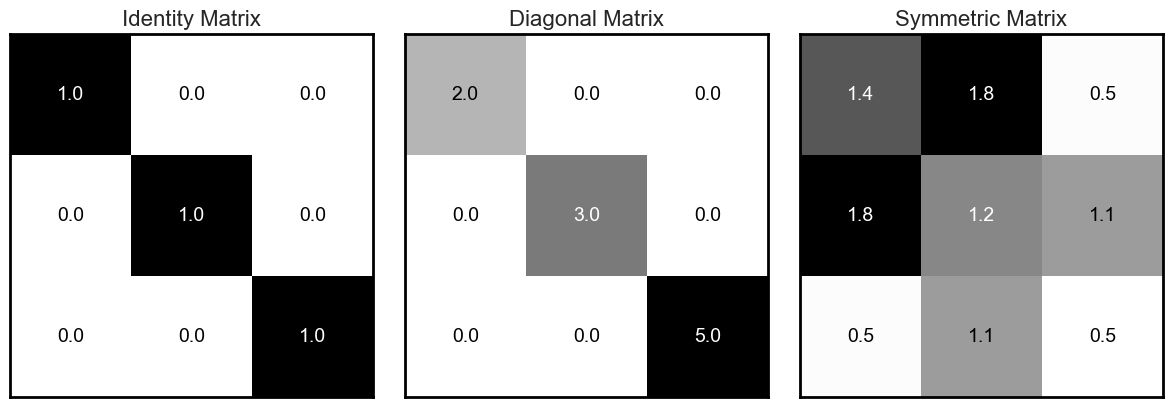

In [21]:

# Visualize these matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
matrices = [I, D, S]
titles = ['Identity Matrix', 'Diagonal Matrix', 'Symmetric Matrix']

for i, (mat, title) in enumerate(zip(matrices, titles)):
    im = axes[i].imshow(mat, cmap='Greys', aspect='equal')
    axes[i].set_title(title, fontsize=16)
    
    # Add text annotations
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            # Use white text on dark background, black text on light background
            text_color = 'white' if mat[r,c] > (mat.min() + mat.max()) / 2 else 'black'
            axes[i].text(c, r, f'{mat[r,c]:.1f}', 
                        ha='center', va='center', fontsize=14,
                        color=text_color)
    
    # Add border and set white background
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_facecolor('white')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

## 7. Matrix Transpose

### Mathematical Definition
The transpose of matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ is $\mathbf{A}^T \in \mathbb{R}^{n \times m}$ where:
$$(\mathbf{A}^T)_{ij} = a_{ji}$$

### Properties
- $(\mathbf{A}^T)^T = \mathbf{A}$
- $(\mathbf{A} + \mathbf{B})^T = \mathbf{A}^T + \mathbf{B}^T$
- $(\mathbf{AB})^T = \mathbf{B}^T\mathbf{A}^T$

In [23]:
# Matrix transpose
A = np.array([[1, 2, 3],
              [4, 5, 6]])

print(f"Original matrix A (2x3):")
print(A)

# Transpose
A_T = A.T
print(f"\nTranspose A^T (3x2):")
print(A_T)

# Alternative method
A_T_alt = np.transpose(A)
print(f"\nUsing np.transpose (same result):")
print(A_T_alt)

# Verify properties
print(f"\nVerifying properties:")
print(f"(A^T)^T == A? {np.array_equal(A_T.T, A)}")

# For matrix multiplication property
B = np.array([[1, 2],
              [3, 4],
              [5, 6]])
AB = A @ B
AB_T = AB.T
BT_AT = B.T @ A.T

print(f"\nMatrix B (3x2):")
print(B)
print(f"\nAB (2x2):")
print(AB)
print(f"\n(AB)^T:")
print(AB_T)
print(f"\nB^T @ A^T:")
print(BT_AT)
print(f"\n(AB)^T == B^T A^T? {np.allclose(AB_T, BT_AT)}")


Original matrix A (2x3):
[[1 2 3]
 [4 5 6]]

Transpose A^T (3x2):
[[1 4]
 [2 5]
 [3 6]]

Using np.transpose (same result):
[[1 4]
 [2 5]
 [3 6]]

Verifying properties:
(A^T)^T == A? True

Matrix B (3x2):
[[1 2]
 [3 4]
 [5 6]]

AB (2x2):
[[22 28]
 [49 64]]

(AB)^T:
[[22 49]
 [28 64]]

B^T @ A^T:
[[22 49]
 [28 64]]

(AB)^T == B^T A^T? True


## 8. Practice Exercises

Work through these exercises to solidify your understanding:


In [10]:
# Practice Exercise: Matrix Operations
print("Practice Exercises:")
print("=" * 30)

# Create random matrices for practice
np.random.seed(123)  # For reproducible results
A = np.random.randint(1, 6, (3, 3))
B = np.random.randint(1, 6, (3, 3))
x = np.random.randint(1, 6, 3)

print(f"Matrix A:")
print(A)
print(f"\nMatrix B:")
print(B)
print(f"\nVector x: {x}")

# Exercise 1: Basic operations
print(f"\nExercise 1: Basic Operations")
print(f"A + B =")
print(A + B)

print(f"\nA - B =")
print(A - B)

print(f"\n2 * A =")
print(2 * A)

# Exercise 2: Matrix multiplication
print(f"\nExercise 2: Matrix Multiplication")
print(f"A @ B =")
print(A @ B)

print(f"\nB @ A =")
print(B @ A)
print(f"\nNote: A @ B ≠ B @ A (matrix multiplication is not commutative!)")

# Exercise 3: Matrix-vector multiplication
print(f"\nExercise 3: Matrix-Vector Multiplication")
y = A @ x
print(f"A @ x = {y}")

# Exercise 4: Transpose properties
print(f"\nExercise 4: Transpose Properties")
AT = A.T
BT = B.T
AB = A @ B
AB_T = AB.T
BT_AT = BT @ AT

print(f"(A @ B)^T =")
print(AB_T)
print(f"\nB^T @ A^T =")
print(BT_AT)
print(f"\nAre they equal? {np.allclose(AB_T, BT_AT)}")

# Exercise 5: Check if matrix is symmetric
print(f"\nExercise 5: Symmetry Check")
S = A @ A.T  # This creates a symmetric matrix
print(f"S = A @ A^T =")
print(S)
print(f"\nIs S symmetric? {np.allclose(S, S.T)}")
print(f"\nS^T =")
print(S.T)

Practice Exercises:
Matrix A:
[[3 5 3]
 [2 4 3]
 [4 2 2]]

Matrix B:
[[1 2 2]
 [1 1 2]
 [4 5 1]]

Vector x: [1 5 2]

Exercise 1: Basic Operations
A + B =
[[4 7 5]
 [3 5 5]
 [8 7 3]]

A - B =
[[ 2  3  1]
 [ 1  3  1]
 [ 0 -3  1]]

2 * A =
[[ 6 10  6]
 [ 4  8  6]
 [ 8  4  4]]

Exercise 2: Matrix Multiplication
A @ B =
[[20 26 19]
 [18 23 15]
 [14 20 14]]

B @ A =
[[15 17 13]
 [13 13 10]
 [26 42 29]]

Note: A @ B ≠ B @ A (matrix multiplication is not commutative!)

Exercise 3: Matrix-Vector Multiplication
A @ x = [34 28 18]

Exercise 4: Transpose Properties
(A @ B)^T =
[[20 18 14]
 [26 23 20]
 [19 15 14]]

B^T @ A^T =
[[20 18 14]
 [26 23 20]
 [19 15 14]]

Are they equal? True

Exercise 5: Symmetry Check
S = A @ A^T =
[[43 35 28]
 [35 29 22]
 [28 22 24]]

Is S symmetric? True

S^T =
[[43 35 28]
 [35 29 22]
 [28 22 24]]


## Key Takeaways

1. **Matrices represent data**: In ML, matrices store datasets and transformations
2. **Matrix multiplication is fundamental**: Core operation in linear algebra and ML
3. **Dimensions must match**: Always check compatibility for operations
4. **Order matters**: Matrix multiplication is not commutative ($\mathbf{AB} \neq \mathbf{BA}$)
5. **Transpose has important properties**: Especially for matrix multiplication
6. **Special matrices have special roles**: Identity, diagonal, and symmetric matrices

## Next Steps

In the next notebook, we'll explore matrix inversion, determinants, and eigenvalues - concepts that are crucial for understanding how machine learning algorithms work under the hood.